# Linear Regression in Jupyter: Normal Equation vs Gradient Descent

> Beginner-friendly lab that mirrors our VS Code scripts and adds richer visuals + interpretation.

## Learning goals
1. Understand the dataset and feature-target relationship.
2. Fit linear regression with two methods:
   - Analytical method: **Normal Equation**
   - Iterative method: **Gradient Descent**
3. Compare model quality using train/test metrics.
4. Learn how to interpret coefficients, MSE, and R^2.

## Ordered pipeline (what we do, in order, and why)
1. **Read data**: load the insurance dataset so we can model real values.
2. **Inspect data**: check shape, summaries, and distributions to avoid blind modeling.
3. **Shuffle + split**: randomize order, then create train/test sets for fair evaluation.
4. **(GD only) Standardize feature**: center/scale bmi so gradient descent updates are stable.
5. **Train model**:
   - Normal Equation solves parameters in one direct step.
   - Gradient Descent learns parameters over epochs.
6. **Learn parameters**: obtain intercept (`w0`) and slope (`w1`).
7. **Evaluate**: use MSE/RMSE/MAE/R^2 and train-vs-test gap.
8. **Interpret**: translate metrics into plain-language business impact.
9. **Iterate if needed**: if quality is weak, tune hyperparameters and/or add better features, then retrain.

## Terminology quick guide
- **Train set**: data used to fit model parameters.
- **Validation set**: optional data used to tune hyperparameters (common in production).
- **Test set**: held-out data for final unbiased evaluation.
- **Epoch**: one full pass through all training rows.
- **Learning rate**: update step size in gradient descent.

## 1) Imports and setup
If a package is missing, run the install cell below, then run this cell again.

In [3]:
# Uncomment and run only if needed
# %pip install pandas numpy matplotlib seaborn kagglehub

from pathlib import Path
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.max_columns', 50)

## 2) Load the same dataset used in the scripts
This cell tries the local project path first. If missing, it uses `kagglehub` to download and cache the dataset.

In [4]:
def resolve_csv_path() -> Path:
    project_csv = Path.cwd() / 'data' / 'insurance-premium-prediction' / 'insurance.csv'
    if project_csv.exists():
        return project_csv

    try:
        import kagglehub
        cached_dir = Path(kagglehub.dataset_download('noordeen/insurance-premium-prediction'))
        cached_csv = cached_dir / 'insurance.csv'
        if cached_csv.exists():
            return cached_csv
    except Exception as ex:
        print('kagglehub fallback failed:', ex)

    raise FileNotFoundError('Could not find insurance.csv in project or kagglehub cache.')

csv_path = resolve_csv_path()
df = pd.read_csv(csv_path)

print('Loaded CSV from:', csv_path)
print('Shape:', df.shape)
df.head()

Loaded CSV from: /Users/nguyenmysan/Desktop/MSBA 265/machine-learning-pathway/Module_02_Linear_Regression/linear-regression/data/insurance-premium-prediction/insurance.csv
Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


## 2.5) Data dictionary (what columns mean)
Use this section before modeling so everyone agrees on what each variable represents.

- `age`: age of the person (years).
- `sex`: biological sex (`male` or `female`) as stored in this dataset.
- `bmi`: Body Mass Index, a weight/height health indicator.
- `children`: number of dependents/children covered by insurance.
- `smoker`: whether the person smokes (`yes`/`no`).
- `region`: residential area category in the US (`northeast`, `northwest`, `southeast`, `southwest`).
- `expenses`: yearly individual medical insurance charges (USD) in this dataset.

Interpretation note:
- `region` is a category label, not a numeric amount.
- `expenses` is the target we are trying to predict.

In [5]:
# Quick confirmation for students: category values and expense scale
print('Unique region values:', sorted(df['region'].dropna().unique().tolist()))
print('Unique smoker values:', sorted(df['smoker'].dropna().unique().tolist()))
print()
print('Expenses summary (USD):')
print(df['expenses'].describe().to_string())

Unique region values: ['northeast', 'northwest', 'southeast', 'southwest']
Unique smoker values: ['no', 'yes']

Expenses summary (USD):
count     1338.000000
mean     13270.422414
std      12110.011240
min       1121.870000
25%       4740.287500
50%       9382.030000
75%      16639.915000
max      63770.430000


## 3) Quick exploratory analysis and visual interpretation
Read this output as *description*, not prediction. We are trying to understand patterns before fitting models.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.665471,6.098382,16.0,26.3,30.4,34.7,53.1
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expenses,1338.0,NaN,NaN,NaN,13270.422414,12110.01124,1121.87,4740.2875,9382.03,16639.915,63770.43


Correlation with expenses:
  age      -> expenses:  0.2990 (weak, positive)
  bmi      -> expenses:  0.1986 (weak, positive)
  children -> expenses:  0.0680 (very weak, positive)


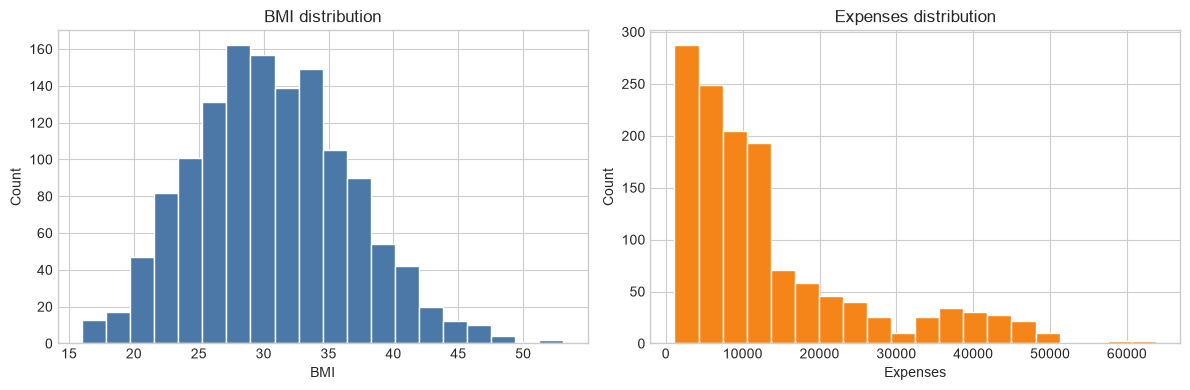

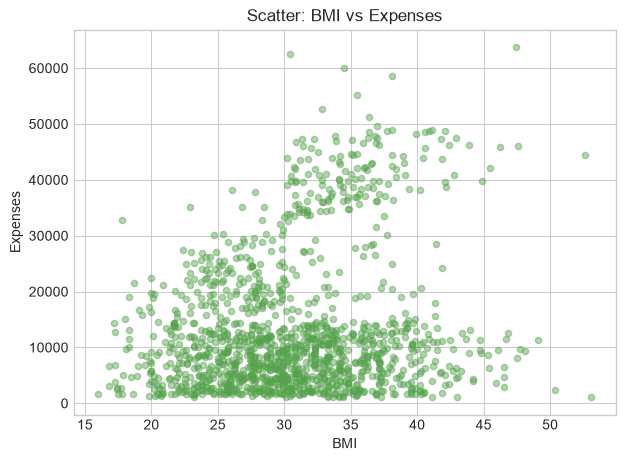

In [6]:
display(df.describe(include='all').T)

corr_cols = ['age', 'bmi', 'children', 'expenses']
corr = df[corr_cols].corr(numeric_only=True)
print('Correlation with expenses:')
for feature in ['age', 'bmi', 'children']:
    r = corr.loc[feature, 'expenses']
    strength = 'very weak' if abs(r) < 0.10 else 'weak' if abs(r) < 0.30 else 'moderate' if abs(r) < 0.50 else 'strong'
    direction = 'positive' if r > 0 else 'negative' if r < 0 else 'no linear'
    print(f'  {feature:8s} -> expenses: {r: .4f} ({strength}, {direction})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['bmi'], bins=20, color='#4C78A8', edgecolor='white')
axes[0].set_title('BMI distribution')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')

axes[1].hist(df['expenses'], bins=20, color='#F58518', edgecolor='white')
axes[1].set_title('Expenses distribution')
axes[1].set_xlabel('Expenses')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(df['bmi'], df['expenses'], alpha=0.45, s=20, color='#54A24B')
plt.title('Scatter: BMI vs Expenses')
plt.xlabel('BMI')
plt.ylabel('Expenses')
plt.show()

## 4) Build a train/test split (educational version)
- **Train set**: fit model parameters.
- **Test set**: final check of performance on unseen data.

In many production workflows, people use train/validation/test. For this beginner lab, we use train/test to keep the idea clear.

In [7]:
# Keep only one feature to match your scripts and make interpretation easy.
x_all = df['bmi'].to_numpy(dtype=float)
y_all = df['expenses'].to_numpy(dtype=float)

seed = 7
rng = np.random.default_rng(seed)
idx = np.arange(len(x_all))
rng.shuffle(idx)

train_ratio = 0.8
split = int(len(idx) * train_ratio)
train_idx, test_idx = idx[:split], idx[split:]

x_train, y_train = x_all[train_idx], y_all[train_idx]
x_test, y_test = x_all[test_idx], y_all[test_idx]

print(f'Train size: {len(x_train)} ({len(x_train)/len(x_all):.1%})')
print(f'Test size:  {len(x_test)} ({len(x_test)/len(x_all):.1%})')

Train size: 1070 (80.0%)
Test size:  268 (20.0%)


## 5) Method A: Normal Equation (Analytical OLS)
Normal Equation uses matrix math to solve weights in one shot:
$$\theta=(X^TX)^{-1}X^Ty$$
For one feature, we can compute equivalent scalar formulas directly.

In [8]:
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def r2_score(y_true, y_pred):
    y_mean = np.mean(y_true)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_mean) ** 2)
    return float(1.0 - (ss_res / ss_tot if ss_tot else 0.0))

def fit_normal_equation_single_feature(x, y):
    n = len(x)
    sum_x = float(np.sum(x))
    sum_y = float(np.sum(y))
    sum_x2 = float(np.sum(x * x))
    sum_xy = float(np.sum(x * y))

    # Solve inverse for 2x2 system corresponding to [w0, w1].
    a, b, c, d = float(n), sum_x, sum_x, sum_x2
    det = a * d - b * c
    if det == 0:
        raise ValueError('Singular matrix; cannot invert X^T X.')

    inv_xtx = np.array([[d / det, -b / det], [-c / det, a / det]])
    xty = np.array([sum_y, sum_xy])
    w0, w1 = inv_xtx @ xty
    return float(w0), float(w1)

w0_ne, w1_ne = fit_normal_equation_single_feature(x_train, y_train)
pred_train_ne = w0_ne + w1_ne * x_train
pred_test_ne = w0_ne + w1_ne * x_test

print(f'Normal Equation line: expenses = {w0_ne:.4f} + {w1_ne:.4f} * bmi')
print(f'Train MSE: {mse(y_train, pred_train_ne):.2f}')
print(f'Test  MSE: {mse(y_test, pred_test_ne):.2f}')
print(f'Train R^2: {r2_score(y_train, pred_train_ne):.4f}')
print(f'Test  R^2: {r2_score(y_test, pred_test_ne):.4f}')

print()
print('Interpretation:')
print(f'- Slope {w1_ne:.2f} means +1 BMI changes predicted expenses by about ${w1_ne:.2f}.')
print('- R^2 tells how much expense variation is explained by this one-feature model.')

Normal Equation line: expenses = 1852.5831 + 369.3363 * bmi
Train MSE: 139969569.72
Test  MSE: 144094972.28
Train R^2: 0.0344
Test  R^2: 0.0554

Interpretation:
- Slope 369.34 means +1 BMI changes predicted expenses by about $369.34.
- R^2 tells how much expense variation is explained by this one-feature model.


## 6) Method B: Gradient Descent (Iterative OLS)
Gradient Descent updates weights repeatedly to reduce error.

- **Optimize** here means: keep adjusting the model parameters (`w0` and `w1`) so prediction error gets as small as possible.
- **Stable optimization** means the training steps behave smoothly and predictably instead of bouncing around wildly.
- **Epoch** in this notebook: one full pass through all training points.
- **Learning rate**: step size for each weight update.

Why standardize here?
- We put `bmi` onto a common scale so gradient descent can train more smoothly.
- This usually makes training more stable and often faster.
- We do **not** need this step for the Normal Equation in this lesson.

Rule of thumb:
- Too small learning rate -> very slow progress.
- Too large learning rate -> unstable/oscillating loss.

### Why this code standardizes `bmi` before Gradient Descent
- Standardizing means recentering the feature around `0` and rescaling it to a standard deviation near `1`.
- This changes the **scale used during training**, not the underlying relationship in the data.
- It helps Gradient Descent take more balanced steps while it optimizes the weights.
- In plain language: the model can "learn" more smoothly instead of wobbling or stepping awkwardly.
- After training, we convert the learned weights back to the original BMI units so the final line is interpretable.

In [9]:
def standardize(x):
    mean = float(np.mean(x))
    std = float(np.std(x))
    if std == 0:
        return np.zeros_like(x), mean, 1.0
    return (x - mean) / std, mean, std

def fit_gradient_descent_single_feature(x, y, learning_rate=0.05, epochs=6000, log_every=500):
    x_std, x_mean, x_std_dev = standardize(x)
    w0, w1 = 0.0, 0.0
    n = len(x_std)
    history = []

    for epoch in range(1, epochs + 1):
        preds = w0 + w1 * x_std
        errors = preds - y

        grad_w0 = (2.0 / n) * np.sum(errors)
        grad_w1 = (2.0 / n) * np.sum(errors * x_std)

        w0 -= learning_rate * grad_w0
        w1 -= learning_rate * grad_w1

        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            loss = mse(y, w0 + w1 * x_std)
            history.append((epoch, loss))

    # Convert back to original feature units.
    slope = w1 / x_std_dev
    intercept = w0 - (w1 * x_mean / x_std_dev)
    return float(intercept), float(slope), history

learning_rate = 0.05
epochs = 6000
w0_gd, w1_gd, loss_history = fit_gradient_descent_single_feature(
    x_train, y_train, learning_rate=learning_rate, epochs=epochs, log_every=500
)

pred_train_gd = w0_gd + w1_gd * x_train
pred_test_gd = w0_gd + w1_gd * x_test

print(f'Gradient Descent line: expenses = {w0_gd:.4f} + {w1_gd:.4f} * bmi')
print(f'learning_rate={learning_rate}, epochs={epochs}')
print(f'Train MSE: {mse(y_train, pred_train_gd):.2f}')
print(f'Test  MSE: {mse(y_test, pred_test_gd):.2f}')
print(f'Train R^2: {r2_score(y_train, pred_train_gd):.4f}')
print(f'Test  R^2: {r2_score(y_test, pred_test_gd):.4f}')

Gradient Descent line: expenses = 1852.5831 + 369.3363 * bmi
learning_rate=0.05, epochs=6000
Train MSE: 139969569.72
Test  MSE: 144094972.28
Train R^2: 0.0344
Test  R^2: 0.0554


,epoch,mse
0,1,2.838603e+08
1,500,1.399696e+08
2,1000,1.399696e+08
3,1500,1.399696e+08
4,2000,1.399696e+08
5,2500,1.399696e+08
6,3000,1.399696e+08
7,3500,1.399696e+08
8,4000,1.399696e+08
9,4500,1.399696e+08


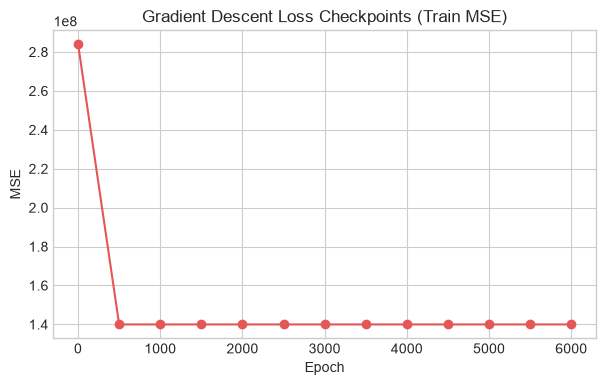

How to interpret this loss curve:
- Falling curve: model is learning.
- Flat curve: model has mostly converged.
- If it bounced up/down wildly, learning_rate would likely be too high.


In [10]:
loss_df = pd.DataFrame(loss_history, columns=['epoch', 'mse'])
display(loss_df.head(10))

plt.figure(figsize=(7, 4))
plt.plot(loss_df['epoch'], loss_df['mse'], marker='o', color='#E45756')
plt.title('Gradient Descent Loss Checkpoints (Train MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()

print('How to interpret this loss curve:')
print('- Falling curve: model is learning.')
print('- Flat curve: model has mostly converged.')
print('- If it bounced up/down wildly, learning_rate would likely be too high.')

## 6.5) Visual experiment: how standardization changes convergence
This experiment compares three setups on the same training task:
- Gradient Descent on the original `bmi` scale with the same learning rate
- Gradient Descent on standardized `bmi` with that same learning rate
- Gradient Descent on the original `bmi` scale again, but with a much smaller learning rate

> Goal: show two things at once:
1. Standardization can make the same learning rate behave much better.
2. Raw features can still work, but they often need more careful tuning.

/var/folders/pf/3ymsjvfs2ll3fgdd8fvvb7bh0000gn/T/ipykernel_59391/3503154316.py:2: RuntimeWarning: overflow encountered in square
  return float(np.mean((y_true - y_pred) ** 2))


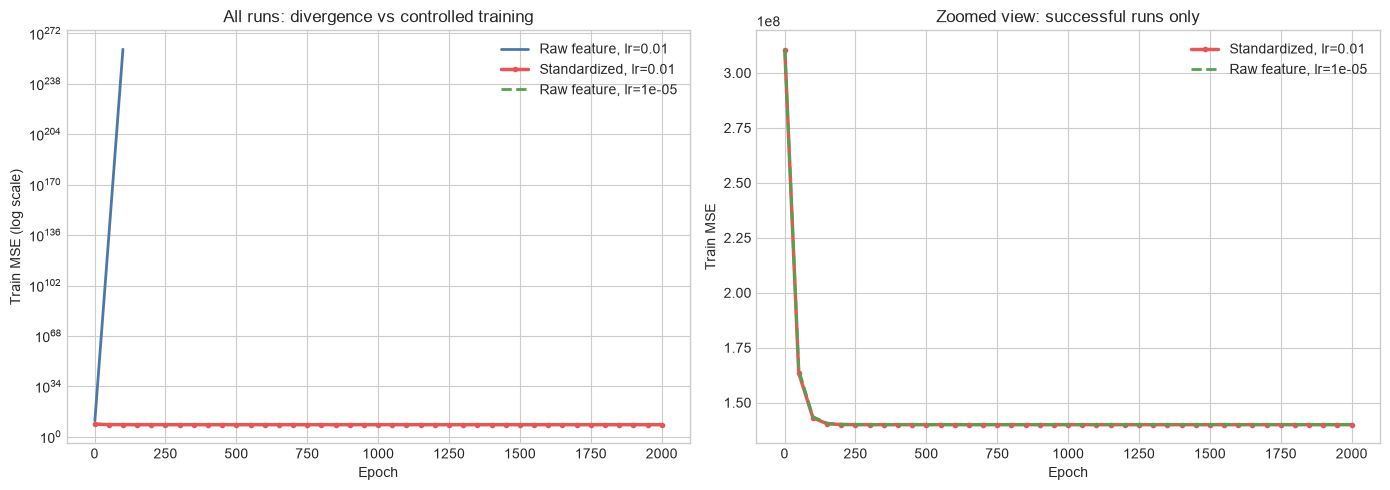

,setup,last_logged_epoch,final_train_mse
0,"Raw feature, lr=0.01",150,inf
1,"Standardized, lr=0.01",2000,1.399696e+08
2,"Raw feature, lr=1e-05",2000,1.400966e+08


Observation: the raw-feature run with the same learning rate diverged.
That means the training steps became too large and the loss blew up instead of shrinking.

Why the red curve was hard to see before:
- The blue diverging run became astronomically large, which forced the first plot onto a huge log scale.
- The green and red successful runs were then compressed near the bottom.
- The zoomed plot on the right isolates the successful runs so the red curve is visible.

How to read this experiment:
- The red curve asks: what happens if we standardize but keep the same learning rate?
- The blue curve asks: what happens if we do not standardize and still keep that same learning rate?
- The green curve asks: can the raw feature work if we tune the learning rate more carefully?
- Lower and smoother curves indicate easier, more stable optimization.


In [11]:
def fit_gd_raw_feature(x, y, learning_rate=0.05, epochs=6000, log_every=100):
    """Gradient Descent on the original feature scale (no standardization)."""
    w0, w1 = 0.0, 0.0
    n = len(x)
    history = []

    for epoch in range(1, epochs + 1):
        preds = w0 + w1 * x
        errors = preds - y

        grad_w0 = (2.0 / n) * np.sum(errors)
        grad_w1 = (2.0 / n) * np.sum(errors * x)

        w0 -= learning_rate * grad_w0
        w1 -= learning_rate * grad_w1

        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            current_mse = mse(y, w0 + w1 * x)
            history.append((epoch, current_mse))
            if not np.isfinite(current_mse):
                break

    return float(w0), float(w1), history

def fit_gd_standardized_feature(x, y, learning_rate=0.05, epochs=6000, log_every=100):
    """Gradient Descent on the standardized feature scale."""
    x_std, x_mean, x_std_dev = standardize(x)
    w0, w1 = 0.0, 0.0
    n = len(x_std)
    history = []

    for epoch in range(1, epochs + 1):
        preds = w0 + w1 * x_std
        errors = preds - y

        grad_w0 = (2.0 / n) * np.sum(errors)
        grad_w1 = (2.0 / n) * np.sum(errors * x_std)

        w0 -= learning_rate * grad_w0
        w1 -= learning_rate * grad_w1

        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            current_mse = mse(y, w0 + w1 * x_std)
            history.append((epoch, current_mse))

    slope = w1 / x_std_dev
    intercept = w0 - (w1 * x_mean / x_std_dev)
    return float(intercept), float(slope), history

exp_epochs = 2000
exp_log_every = 50
same_lr = 0.01
smaller_raw_lr = 0.00001

raw_w0_same, raw_w1_same, raw_history_same = fit_gd_raw_feature(
    x_train, y_train, learning_rate=same_lr, epochs=exp_epochs, log_every=exp_log_every
)
std_w0, std_w1, std_history = fit_gd_standardized_feature(
    x_train, y_train, learning_rate=same_lr, epochs=exp_epochs, log_every=exp_log_every
)
raw_w0_small, raw_w1_small, raw_history_small = fit_gd_raw_feature(
    x_train, y_train, learning_rate=smaller_raw_lr, epochs=exp_epochs, log_every=exp_log_every
)

raw_df_same = pd.DataFrame(raw_history_same, columns=['epoch', 'mse'])
std_df = pd.DataFrame(std_history, columns=['epoch', 'mse'])
raw_df_small = pd.DataFrame(raw_history_small, columns=['epoch', 'mse'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: all three runs, including divergence story.
axes[0].plot(
    raw_df_same['epoch'], raw_df_same['mse'],
    label=f'Raw feature, lr={same_lr}', color='#4C78A8', linewidth=2, zorder=1
 )
axes[0].plot(
    std_df['epoch'], std_df['mse'],
    label=f'Standardized, lr={same_lr}', color='#E45756', linewidth=2.5, marker='o', markersize=3, zorder=3
 )
axes[0].plot(
    raw_df_small['epoch'], raw_df_small['mse'],
    label=f'Raw feature, lr={smaller_raw_lr}', color='#54A24B', linewidth=2, linestyle='--', zorder=2
 )
axes[0].set_yscale('log')
axes[0].set_title('All runs: divergence vs controlled training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train MSE (log scale)')
axes[0].legend()

# Plot 2: zoom on the two successful runs so the standardized curve is visible.
axes[1].plot(
    std_df['epoch'], std_df['mse'],
    label=f'Standardized, lr={same_lr}', color='#E45756', linewidth=2.5, marker='o', markersize=3
 )
axes[1].plot(
    raw_df_small['epoch'], raw_df_small['mse'],
    label=f'Raw feature, lr={smaller_raw_lr}', color='#54A24B', linewidth=2, linestyle='--'
 )
axes[1].set_title('Zoomed view: successful runs only')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Train MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

comparison_convergence = pd.DataFrame({
    'setup': [f'Raw feature, lr={same_lr}', f'Standardized, lr={same_lr}', f'Raw feature, lr={smaller_raw_lr}'],
    'last_logged_epoch': [raw_df_same['epoch'].iloc[-1], std_df['epoch'].iloc[-1], raw_df_small['epoch'].iloc[-1]],
    'final_train_mse': [raw_df_same['mse'].iloc[-1], std_df['mse'].iloc[-1], raw_df_small['mse'].iloc[-1]],
})
display(comparison_convergence)

same_lr_diverged = not np.isfinite(raw_df_same['mse'].iloc[-1])
if same_lr_diverged:
    print('Observation: the raw-feature run with the same learning rate diverged.')
    print('That means the training steps became too large and the loss blew up instead of shrinking.')
    print()

print('Why the red curve was hard to see before:')
print('- The blue diverging run became astronomically large, which forced the first plot onto a huge log scale.')
print('- The green and red successful runs were then compressed near the bottom.')
print('- The zoomed plot on the right isolates the successful runs so the red curve is visible.')
print()
print('How to read this experiment:')
print('- The red curve asks: what happens if we standardize but keep the same learning rate?')
print('- The blue curve asks: what happens if we do not standardize and still keep that same learning rate?')
print('- The green curve asks: can the raw feature work if we tune the learning rate more carefully?')
print('- Lower and smoother curves indicate easier, more stable optimization.')

## 7) Side-by-side model comparison and visuals
This section answers: do both methods produce similar models on this dataset?

,model,intercept_w0,slope_w1,train_mse,test_mse,train_r2,test_r2
0,Normal Equation,1852.583108,369.336255,1.399696e+08,1.440950e+08,0.0344,0.055351
1,Gradient Descent,1852.583108,369.336255,1.399696e+08,1.440950e+08,0.0344,0.055351


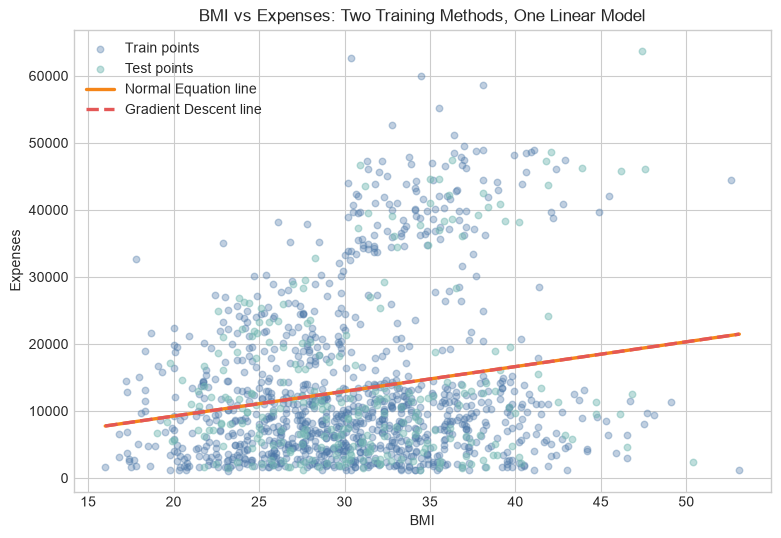

Interpretation checkpoint:
- If metrics and lines are very similar, both methods found nearly the same optimum.
- Normal Equation is direct math; Gradient Descent is iterative optimization.
- In larger/high-dimensional settings, Gradient Descent is usually more scalable.


In [12]:
comparison = pd.DataFrame({
    'model': ['Normal Equation', 'Gradient Descent'],
    'intercept_w0': [w0_ne, w0_gd],
    'slope_w1': [w1_ne, w1_gd],
    'train_mse': [mse(y_train, pred_train_ne), mse(y_train, pred_train_gd)],
    'test_mse': [mse(y_test, pred_test_ne), mse(y_test, pred_test_gd)],
    'train_r2': [r2_score(y_train, pred_train_ne), r2_score(y_train, pred_train_gd)],
    'test_r2': [r2_score(y_test, pred_test_ne), r2_score(y_test, pred_test_gd)],
})
display(comparison)

x_line = np.linspace(np.min(x_all), np.max(x_all), 200)
y_line_ne = w0_ne + w1_ne * x_line
y_line_gd = w0_gd + w1_gd * x_line

plt.figure(figsize=(9, 6))
plt.scatter(x_train, y_train, alpha=0.35, s=22, label='Train points', color='#4C78A8')
plt.scatter(x_test, y_test, alpha=0.45, s=22, label='Test points', color='#72B7B2')
plt.plot(x_line, y_line_ne, linewidth=2.4, label='Normal Equation line', color='#F58518')
plt.plot(x_line, y_line_gd, linewidth=2.4, linestyle='--', label='Gradient Descent line', color='#E45756')
plt.title('BMI vs Expenses: Two Training Methods, One Linear Model')
plt.xlabel('BMI')
plt.ylabel('Expenses')
plt.legend()
plt.show()

print('Interpretation checkpoint:')
print('- If metrics and lines are very similar, both methods found nearly the same optimum.')
print('- Normal Equation is direct math; Gradient Descent is iterative optimization.')
print('- In larger/high-dimensional settings, Gradient Descent is usually more scalable.')

## 8) Next experiment ideas (for class activity)
1. Try different learning rates: `0.1, 0.05, 0.01, 0.001` and compare loss curves.
2. Add more features (`age`, `children`, smoker encoding) and observe R^2 changes.
3. Add a validation split (train/val/test) and tune learning rate using validation only.
4. Compare feature scaling vs no scaling for gradient descent speed.

## 9) Real-world interpretation guide (important)
### What does mostly converged mean?
- It means the loss is no longer changing much across later epochs.
- In practice, that means more training epochs likely give very small gains.

### If setup needs tuning, what should we check?
1. Learning rate (too high can oscillate/diverge; too low can be very slow).
2. Feature scaling (important for gradient descent stability).
3. Number of epochs (enough to converge, not wasteful).
4. Feature quality (single-feature models can underfit).
5. Data quality (outliers, leakage, missingness, wrong units).

### Is there a max MSE?
- No universal max. MSE depends on target scale.
- Judge MSE relative to:
  - baseline predictor (predicting mean target)
  - RMSE in target units
  - business tolerance for error

### Should test error be lower than train error?
- Usually train error is lower.
- Slightly lower test error can happen due to random split variation.
- A large train-test gap usually indicates overfitting.

### Real-world split strategy
- For real projects, yes: prefer **train/validation/test** (or cross-validation).
- Tune hyperparameters on validation only.
- Keep test set untouched for final report.

### Stakeholder wording tip
- Instead of saying "explains 2-4% of variation," say:
  "The model captures only a small part of the cost pattern, so most cost differences are still unexplained."

### What to take into stakeholder meetings
1. Data scope and split strategy.
2. Baseline vs model metrics (RMSE, MAE, R^2).
3. Practical interpretation (typical error in dollars).
4. Known limitations and next steps.

In [13]:
# Metrics helper for stakeholder-ready reporting
def mae_np(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def summarize_model(y_true_train, y_pred_train, y_true_test, y_pred_test, model_name):
    train_mse = float(np.mean((y_true_train - y_pred_train) ** 2))
    test_mse = float(np.mean((y_true_test - y_pred_test) ** 2))
    train_rmse = float(np.sqrt(train_mse))
    test_rmse = float(np.sqrt(test_mse))
    train_mae = mae_np(y_true_train, y_pred_train)
    test_mae = mae_np(y_true_test, y_pred_test)
    train_r2 = r2_score(y_true_train, y_pred_train)
    test_r2 = r2_score(y_true_test, y_pred_test)

    baseline = float(np.mean(y_true_train))
    baseline_test_mse = float(np.mean((y_true_test - baseline) ** 2))

    return {
        'model': model_name,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'baseline_test_mse': baseline_test_mse,
        'test_minus_train_mse': test_mse - train_mse,
    }

report_ne = summarize_model(y_train, pred_train_ne, y_test, pred_test_ne, 'Normal Equation')
report_gd = summarize_model(y_train, pred_train_gd, y_test, pred_test_gd, 'Gradient Descent')

report_df = pd.DataFrame([report_ne, report_gd])
display(report_df)

for row in [report_ne, report_gd]:
    print(f"\n{row['model']} summary:")
    pattern_pct = row['test_r2'] * 100
    print(f"- Captures about {pattern_pct:.2f}% of the cost pattern in unseen data.")
    print('- Plain language: most cost differences between people are still unexplained by this simple model.')
    print(f"- Typical prediction error: ${row['test_rmse']:.2f} (RMSE)")
    print(f"- Baseline test MSE: {row['baseline_test_mse']:.2f}")
    print(f"- Model test MSE:    {row['test_mse']:.2f}")
    if row['test_mse'] < row['baseline_test_mse']:
        print('- Better than mean-baseline on this split.')
    else:
        print('- Not beating mean-baseline on this split.')
    gap = row['test_minus_train_mse']
    print(f"- Generalization gap (test - train MSE): {gap:.2f}")
    if gap > 0:
        print('- Test error > train error (common pattern).')
    else:
        print('- Test error <= train error (possible by random split).')

# Three ready-to-read bullets for stakeholder meetings (using GD row here).
row = report_gd
pattern_pct = row['test_r2'] * 100
target_mean = float(np.mean(y_test))
relative_err = (row['test_rmse'] / target_mean) * 100 if target_mean else 0.0

print('\nThree meeting bullets:')
print(f"1. Current performance: this model captures about {pattern_pct:.2f}% of the cost pattern.")
print(f"2. Practical impact: typical miss is about ${row['test_rmse']:.2f} (~{relative_err:.1f}% of average cost).")
print('3. Action plan: use this as a baseline and add stronger features before business use.')

,model,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,baseline_test_mse,test_minus_train_mse
0,Normal Equation,1.399696e+08,1.440950e+08,11830.873582,12003.956526,9086.77686,9289.788854,0.0344,0.055351,1.529629e+08,4.125403e+06
1,Gradient Descent,1.399696e+08,1.440950e+08,11830.873582,12003.956526,9086.77686,9289.788854,0.0344,0.055351,1.529629e+08,4.125403e+06



Normal Equation summary:
- Captures about 5.54% of the cost pattern in unseen data.
- Plain language: most cost differences between people are still unexplained by this simple model.
- Typical prediction error: $12003.96 (RMSE)
- Baseline test MSE: 152962941.21
- Model test MSE:    144094972.28
- Better than mean-baseline on this split.
- Generalization gap (test - train MSE): 4125402.56
- Test error > train error (common pattern).

Gradient Descent summary:
- Captures about 5.54% of the cost pattern in unseen data.
- Plain language: most cost differences between people are still unexplained by this simple model.
- Typical prediction error: $12003.96 (RMSE)
- Baseline test MSE: 152962941.21
- Model test MSE:    144094972.28
- Better than mean-baseline on this split.
- Generalization gap (test - train MSE): 4125402.56
- Test error > train error (common pattern).

Three meeting bullets:
1. Current performance: this model captures about 5.54% of the cost pattern.
2. Practical impact: typ